In [80]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from math import sqrt
from sklearn.model_selection import GridSearchCV
from scipy.stats import gaussian_kde

In [81]:
# Load the dataset
Cars_df = pd.read_csv('Cars.csv')

In [82]:
# Drop rows with any missing values
data_frame = Cars_df.dropna()

In [83]:
data_frame = pd.read_csv('Cars.csv')

# Applying log transformation to the 'Price' column to reduce skewness
data_frame['Log_Price'] = np.log1p(data_frame['Price'])  # log1p is used to handle zero values in the data


filtered_file_path = 'Cars_Filtered.csv'
data_frame.to_csv(filtered_file_path, index=False)

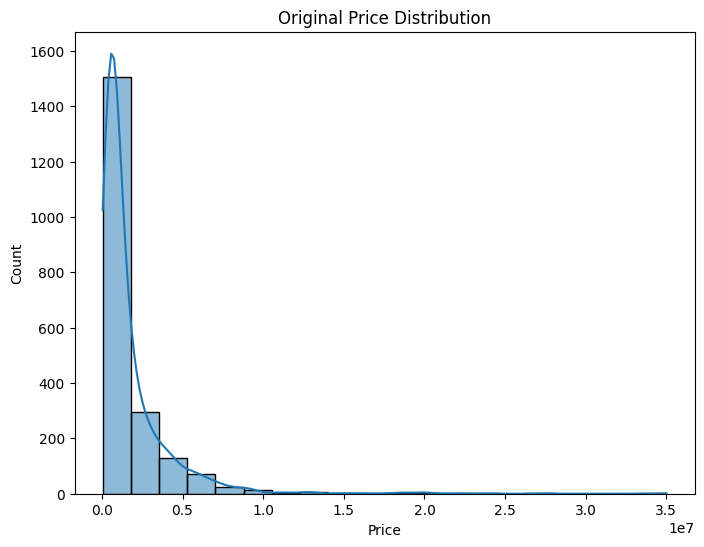

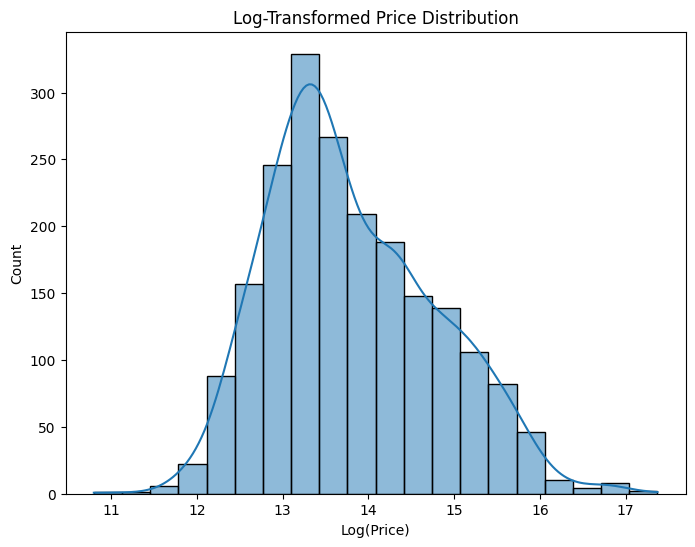

In [84]:
# Plotting the distribution of the original 'Price'
plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Price'], bins=20, kde=True)
plt.title('Original Price Distribution')
plt.xlabel('Price')
plt.show()


# Plotting the distribution of the log-transformed 'Price'
plt.figure(figsize=(8, 6))
sns.histplot(data=data_frame['Log_Price'], bins=20, kde=True)
plt.title('Log-Transformed Price Distribution')
plt.xlabel('Log(Price)')
plt.show()

In [85]:
label_encoder = LabelEncoder()

In [86]:
data_frame['Transmission ID'] = label_encoder.fit_transform(data_frame['Transmission'])
Transmission = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

In [87]:
data_frame['Power'] = data_frame['Max Power'].str.replace(r' bhp @ \d+ rpm', '', regex=True)
# Convert the attribute to a numeric type
data_frame['Power'] = pd.to_numeric(data_frame['Power'], errors='coerce')

In [88]:
# Identify columns that have data type 'object' (text)
text_columns = data_frame.select_dtypes(include=['object']).columns
# Drop the identified text columns
data_frame = data_frame.drop(text_columns, axis=1)
data_frame = data_frame.dropna()
data_frame.to_csv('Cars_Encoded.csv', index=False)

In [89]:
Aim_Price = data_frame["Log_Price"]
data_frame = data_frame.drop(["Log_Price"],axis=1)
data_frame["Aim_Price"]= Aim_Price
data_frame.to_csv("Cars_Final.csv")

In [90]:
data_frame = data_frame[['Year','Seating Capacity', 'Transmission ID','Power','Aim_Price']]

In [91]:
X = data_frame[['Year','Seating Capacity', 'Transmission ID','Power']]

In [92]:
y = data_frame['Aim_Price']

In [93]:
# Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

In [94]:
knn_model = KNeighborsRegressor(n_neighbors=10)

In [95]:
# Training
knn_model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=10)

In [96]:
# Testing
train_preds = knn_model.predict(X_train)

In [97]:
# Performance Metrics
mse = mean_squared_error(y_train, train_preds)
rmse = sqrt(mse)
r2_score = knn_model.score(X_test,y_test)
print(mse)
print(rmse)
print(r2_score*100,'%')

0.06654712739782387
0.25796729908619015
90.71870757318295 %


Tunning and Improving the model

In [98]:
parameters = {"n_neighbors": range(1, 10)}

In [99]:
gridsearch = GridSearchCV(knn_model, parameters)
gridsearch.fit(X_train, y_train)

GridSearchCV(estimator=KNeighborsRegressor(n_neighbors=10),
             param_grid={'n_neighbors': range(1, 10)})

In [100]:
gridsearch.best_params_

{'n_neighbors': 3}

In [101]:
# Training
train_preds_grid = gridsearch.predict(X_train)

test_preds_grid = gridsearch.predict(X_test)

In [102]:
# Performance Metrics

test_mse = mean_squared_error(y_test, test_preds_grid)
test_rmse = sqrt(test_mse)
r2_score = gridsearch.score(X_test,y_test)
print("MSE : ", test_mse)
print("RMSE : ", test_rmse)
print("R2 Score : ",r2_score*100,'%')

MSE :  0.06406459634985714
RMSE :  0.25310985036117645
R2 Score :  92.12791085479576 %


From what I understood, the gridsearch is a way to determine the best value of K.

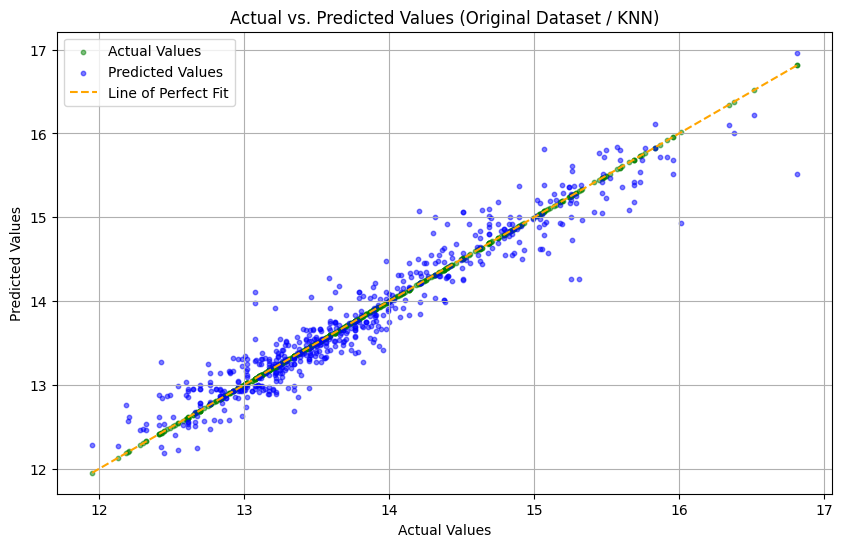

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot the actual values in green, with smaller circles
plt.scatter(y_test, y_test, color='green', s=10, alpha=0.5, label='Actual Values')

# Plot the predicted values in blue, with smaller circles
plt.scatter(y_test, test_preds_grid, color='blue', s=10, alpha=0.5, label='Predicted Values')

# Add an orange line for perfect predictions
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='orange', linestyle='--', label='Line of Perfect Fit')

plt.title('Actual vs. Predicted Values (Original Dataset / KNN)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()
plt.show()


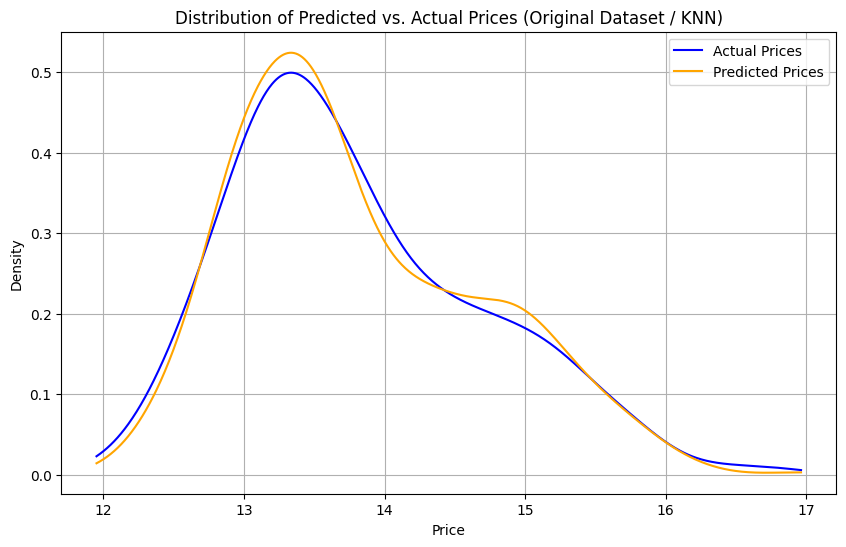

In [104]:
# Set up the figure and axis
plt.figure(figsize=(10, 6))

# Calculate the density using Gaussian Kernel Density Estimation
density_actual = gaussian_kde(y_test)
density_pred = gaussian_kde(test_preds_grid)

# Set up a range of values for x
x_vals = np.linspace(min(min(y_test), min(test_preds_grid)), max(max(y_test), max(test_preds_grid)), 1000)

# Calculate the density values for each range
y_actual = density_actual(x_vals)
y_pred = density_pred(x_vals)

# Plotting the density estimates as lines
plt.plot(x_vals, y_actual, label='Actual Prices', color='blue')
plt.plot(x_vals, y_pred, label='Predicted Prices', color='orange')

# Adding titles and labels
plt.title('Distribution of Predicted vs. Actual Prices (Original Dataset / KNN)')
plt.xlabel('Price')
plt.ylabel('Density')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()